## โค้ด 10.1 Diffusions Model
โมเดลนี้ ไม่ได้สร้างภาพใหม่
แต่เรียนรู้ว่า noise ที่ควรถูกลบคืออะไร


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 0 | Loss: 1.0248
Epoch 300 | Loss: 0.4602
Epoch 600 | Loss: 0.0755
Epoch 900 | Loss: 0.1084
Epoch 1200 | Loss: 0.0584
Epoch 1500 | Loss: 0.0592
Epoch 1800 | Loss: 0.0540
Epoch 2100 | Loss: 0.0450
Epoch 2400 | Loss: 0.0500
Epoch 2700 | Loss: 0.0441


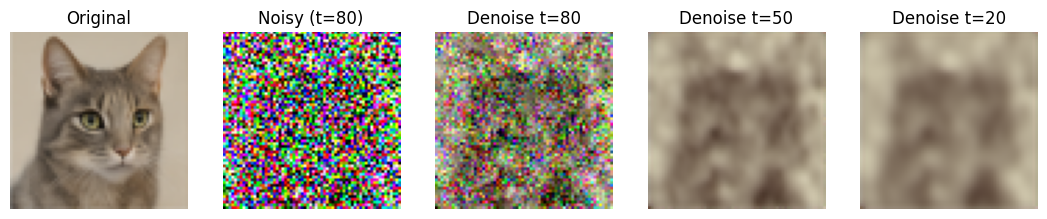

In [ ]:
# =========================================
# Simple Diffusion Model (Level 1)
# Show Forward + Reverse clearly
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------
# 1) Mount Google Drive
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

IMAGE_PATH = '/content/drive/MyDrive/aiforeveryone/cnn/cats/cat1.jpg'

# ---------------------------
# 2) Load & preprocess image
# ---------------------------
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])

img = Image.open(IMAGE_PATH).convert('RGB')
x0 = transform(img).unsqueeze(0)  # (1, 3, 64, 64)

# ---------------------------
# 3) Diffusion parameters
# ---------------------------
T_steps = 100
betas = torch.linspace(0.0001, 0.02, T_steps)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

# ---------------------------
# 4) Simple CNN (Noise Predictor)
# ---------------------------
class SimpleDiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleDiffusionNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ---------------------------
# 5) Training (single image)
# ---------------------------
epochs = 3000

for epoch in range(epochs):
    t = torch.randint(0, T_steps, (1,))
    noise = torch.randn_like(x0)

    xt = torch.sqrt(alpha_bar[t]) * x0 + torch.sqrt(1 - alpha_bar[t]) * noise
    noise_pred = model(xt)

    loss = loss_fn(noise_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# ---------------------------
# 6) Forward Diffusion (add noise & show)
# ---------------------------
t_start = 80
noise = torch.randn_like(x0)

x_noisy = (
    torch.sqrt(alpha_bar[t_start]) * x0 +
    torch.sqrt(1 - alpha_bar[t_start]) * noise
)

# ใช้ภาพ noisy นี้เป็นจุดเริ่ม reverse
x = x_noisy.clone()

# ---------------------------
# 7) Reverse Diffusion
# ---------------------------
steps_to_show = [80, 50, 20, 0]
results = []

for t in reversed(range(t_start)):
    with torch.no_grad():
        eps = model(x)
        x = (x - (1 - alphas[t]) / torch.sqrt(1 - alpha_bar[t]) * eps) \
            / torch.sqrt(alphas[t])

    if t in steps_to_show:
        results.append(x.clone())

# ---------------------------
# 8) Visualization
# ---------------------------
def show(img_tensor, title):
    img = img_tensor.squeeze().permute(1, 2, 0).clamp(0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(16, 4))

plt.subplot(1, 6, 1)
show(x0, "Original")

plt.subplot(1, 6, 2)
show(x_noisy, f"Noisy (t={t_start})")

for i, r in enumerate(results):
    plt.subplot(1, 6, i + 3)
    show(r, f"Denoise t={steps_to_show[i]}")

plt.show()


## โค้ดแสดงการสร้างภาพที่ถูกเติม Noise ใน Diffusion model

กรุณาอัปโหลดภาพ (เช่น .jpg / .png)


Saving IMG_0561.jpeg to IMG_0561 (2).jpeg
รูปที่ใช้เทรน มี shape: torch.Size([1, 3, 64, 64])
step 200/2000, loss = 0.087138
step 400/2000, loss = 0.046107
step 600/2000, loss = 0.039204
step 800/2000, loss = 0.055886
step 1000/2000, loss = 0.032015
step 1200/2000, loss = 0.039204
step 1400/2000, loss = 0.028002
step 1600/2000, loss = 0.025588
step 1800/2000, loss = 0.170568
step 2000/2000, loss = 0.047787
Training finished.
กำลัง sample ภาพใหม่จาก noise ...


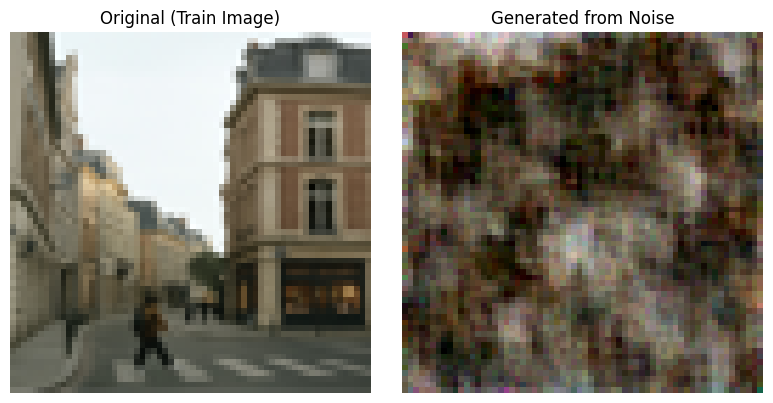

In [ ]:
# ============================================
# Simple DDPM-like Diffusion Model Demo (Single Image)
# - Run on Google Colab
# - Upload 1 image as training target
# - Train tiny diffusion model on that image
# - Sample new image from pure noise
# ============================================

# 1. (ถ้าใช้ Colab) ติดตั้ง PyTorch ถ้ายังไม่มี
# ถ้าเครื่องคุณติดตั้งแล้ว สามารถคอมเมนต์บรรทัดนี้ออกได้
#!pip install torch torchvision --quiet

from google.colab import files

import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# 2. อัปโหลดภาพ
# -----------------------------
print("กรุณาอัปโหลดภาพ (เช่น .jpg / .png)")
uploaded = files.upload()

filename = next(iter(uploaded.keys()))
img = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

# ปรับขนาดให้เล็กหน่อย เพื่อให้เทรนเร็วขึ้น
IMAGE_SIZE = 64
img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

# แปลงเป็น tensor ช่วง [0, 1]
img_np = np.array(img) / 255.0  # (H, W, C)
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float()  # (1, 3, H, W)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_tensor = img_tensor.to(device)

print("รูปที่ใช้เทรน มี shape:", img_tensor.shape)

# -----------------------------
# 3. กำหนด Diffusion Hyperparameters
# -----------------------------
T = 200  # จำนวน time steps ของ diffusion (ลด/เพิ่มได้)
betas = torch.linspace(1e-4, 0.02, T).to(device)  # linear schedule

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]], dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    """
    ดึงค่า a[t] แล้ว reshape ให้อยู่ในรูป (B,1,1,1) เพื่อ broadcast กับ x
    a: tensor shape (T,)
    t: LongTensor shape (B,)
    """
    out = a.gather(-1, t)  # (B,)
    return out.view(-1, 1, 1, 1).expand(x_shape)

def q_sample(x_start, t, noise):
    """
    ส่ง x_0 + t + noise → ได้ x_t ตาม forward process:
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    """
    return (
        extract(sqrt_alphas_cumprod, t, x_start.shape) * x_start
        + extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape) * noise
    )

# -----------------------------
# 4. นิยามโมเดลเล็ก ๆ (Tiny CNN + time as extra channel)
# -----------------------------
class TinyDiffusionModel(nn.Module):
    def __init__(self, img_channels=3, base_channels=64):
        super().__init__()
        # รับช่องภาพ + 1 ช่องสำหรับเวลา t
        self.conv1 = nn.Conv2d(img_channels + 1, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(base_channels, img_channels, 3, padding=1)

    def forward(self, x, t):
        """
        x: (B, 3, H, W)
        t: (B,) time step
        """
        B, C, H, W = x.shape

        # แปลง t เป็นค่าในช่วง [0, 1] แล้วขยายให้เป็น map ขนาด H×W
        t_norm = t.float() / (T - 1)
        t_map = t_norm.view(B, 1, 1, 1).expand(B, 1, H, W)

        # concat เข้ากับช่องภาพ
        x_in = torch.cat([x, t_map], dim=1)  # (B, C+1, H, W)

        h = F.relu(self.conv1(x_in))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        out = self.conv4(h)  # ทำนาย noise epsilon_hat

        return out

model = TinyDiffusionModel().to(device)

# -----------------------------
# 5. เทรนโมเดลบนภาพเดียว (overfit) เพื่อสาธิตหลักการ
# -----------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
x0 = img_tensor  # (1, 3, H, W)

NUM_STEPS = 2000  # จำนวน step เทรน (น้อยๆ สำหรับ demo; เพิ่มได้ถ้าต้องการคุณภาพดีขึ้น)

for step in range(1, NUM_STEPS + 1):
    model.train()
    # สุ่ม time t (batch size = 1)
    t = torch.randint(0, T, (1,), device=device).long()

    # สุ่ม noise แล้วสร้าง x_t
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)

    # โมเดลพยายามทำนาย noise กลับมา
    pred_noise = model(x_t, t)
    loss = F.mse_loss(pred_noise, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print(f"step {step}/{NUM_STEPS}, loss = {loss.item():.6f}")

print("Training finished.")

# -----------------------------
# 6. ฟังก์ชันสร้างภาพใหม่จาก noise (reverse process)
# -----------------------------
@torch.no_grad()
def p_sample(x, t):
    """
    1 step ของ reverse:
    x_t → x_{t-1}
    """
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # ทำนาย noise ด้วยโมเดล
    eps_theta = model(x, t)

    # mean ของ posterior q(x_{t-1} | x_t, x_0) ในรูปที่ใช้ eps-prediction
    model_mean = sqrt_recip_alphas_t * (x - betas_t * eps_theta / sqrt_one_minus_alphas_cumprod_t)

    if t[0] == 0:
        return model_mean
    else:
        posterior_var_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_var_t) * noise

@torch.no_grad()
def p_sample_loop(shape):
    """
    เริ่มจาก noise ล้วน แล้วไล่ t: T-1 → 0
    """
    x = torch.randn(shape, device=device)
    for i in reversed(range(T)):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        x = p_sample(x, t)
    return x

# -----------------------------
# 7. สร้างภาพใหม่จาก noise ล้วน
# -----------------------------
print("กำลัง sample ภาพใหม่จาก noise ...")
sampled = p_sample_loop(x0.shape)  # shape เดียวกับภาพต้นฉบับ

# -----------------------------
# 8. แสดงผลเปรียบเทียบ
# -----------------------------
def show_tensor_image(tensor, title=""):
    """
    tensor: (1, C, H, W) หรือ (C, H, W)
    """
    if tensor.dim() == 4:
        tensor = tensor[0]
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0.0, 1.0)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
show_tensor_image(x0, "Original (Train Image)")

plt.subplot(1,2,2)
show_tensor_image(sampled, "Generated from Noise")

plt.tight_layout()
plt.show()


##โค้ด Diffusion model ใช้ U-Net เป็น Backbone

Saving IMG_0561.jpeg to IMG_0561 (4).jpeg
Start training...
Epoch 1/50 - loss: 0.952256
Epoch 2/50 - loss: 0.865790
Epoch 3/50 - loss: 0.809696
Epoch 4/50 - loss: 0.768201
Epoch 5/50 - loss: 0.738931
Epoch 6/50 - loss: 0.709819
Epoch 7/50 - loss: 0.683987
Epoch 8/50 - loss: 0.668521
Epoch 9/50 - loss: 0.641143
Epoch 10/50 - loss: 0.630519
Epoch 11/50 - loss: 0.620922
Epoch 12/50 - loss: 0.607942
Epoch 13/50 - loss: 0.603422
Epoch 14/50 - loss: 0.590491
Epoch 15/50 - loss: 0.577830
Epoch 16/50 - loss: 0.581138
Epoch 17/50 - loss: 0.567249
Epoch 18/50 - loss: 0.564117
Epoch 19/50 - loss: 0.554559
Epoch 20/50 - loss: 0.552030
Epoch 21/50 - loss: 0.538577
Epoch 22/50 - loss: 0.540884
Epoch 23/50 - loss: 0.532455
Epoch 24/50 - loss: 0.527168
Epoch 25/50 - loss: 0.519765
Epoch 26/50 - loss: 0.523772
Epoch 27/50 - loss: 0.514563
Epoch 28/50 - loss: 0.513826
Epoch 29/50 - loss: 0.506519
Epoch 30/50 - loss: 0.505355
Epoch 31/50 - loss: 0.500880
Epoch 32/50 - loss: 0.493986
Epoch 33/50 - loss: 0

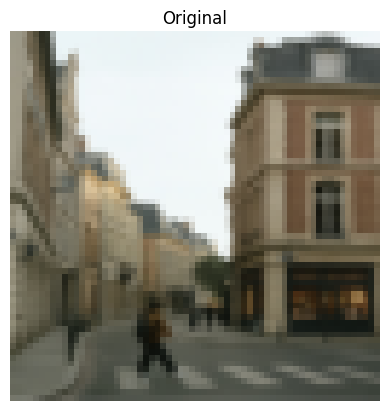

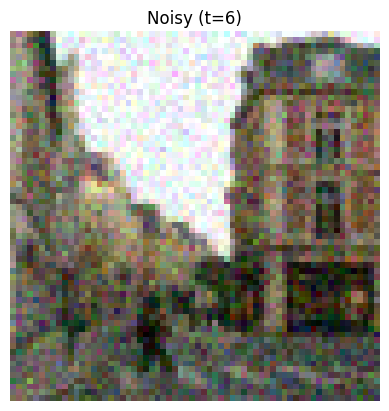

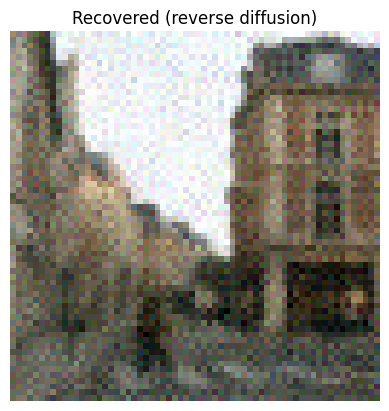

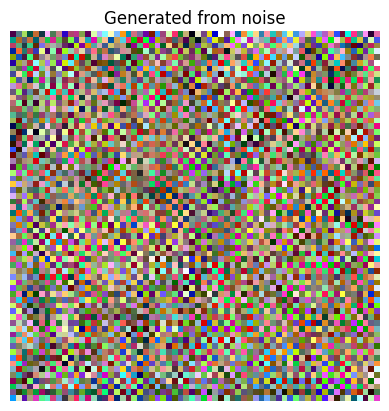

In [ ]:
# ============================================================
# Simple Diffusion Model Demo (single file)
# - Upload 1 image
# - Train simple noise-prediction model
# - Forward diffusion (add noise)
# - Reverse diffusion (denoise + generate new image)
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Upload image (for Google Colab)
#    ถ้าไม่ได้ใช้ Colab ให้คอมเมนต์ส่วนนี้ แล้วกำหนด path เอง
# ------------------------------------------------------------
try:
    from google.colab import files
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
except Exception as e:
    print("Not running on Colab or upload failed. Set image_path manually!")
    image_path = "your_image.jpg"  # แก้เป็น path ของคุณ

# ------------------------------------------------------------
# 1. Config & device
# ------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 64       # resize เป็น 64x64
BATCH_SIZE = 16
EPOCHS = 50         # เดโม่ ถ้าอยากดีขึ้น เพิ่ม epoch
T = 20             # จำนวน diffusion steps

# ------------------------------------------------------------
# 2. Load & preprocess image
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                  # [0,1]
])

img_pil = Image.open(image_path).convert("RGB")
img_tensor = transform(img_pil)            # shape: (3, H, W)
img_tensor = img_tensor * 2.0 - 1.0        # map [0,1] -> [-1,1]

# ใส่ batch dimension
img_tensor = img_tensor.unsqueeze(0).to(device)  # (1,3,H,W)

# ------------------------------------------------------------
# 3. Diffusion schedule & helper functions
# ------------------------------------------------------------
def make_beta_schedule(timesteps, start=1e-4, end=0.02):
    """
    Linear beta schedule: beta_t จาก start -> end
    """
    return torch.linspace(start, end, timesteps)

betas = make_beta_schedule(T).to(device)                # (T,)
alphas = 1.0 - betas                                    # (T,)
alphas_cumprod = torch.cumprod(alphas, dim=0)           # (T,)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)        # (T,)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)  # (T,)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)            # (T,)
betas_sqrt = torch.sqrt(betas)                          # (T,)

def get_index_from_list(vals, t, x_shape):
    """
    ดึงค่าจาก list (vals) ตามเวลา t แล้ว reshape ให้อยู่ในรูป (B,1,1,1) เพื่อ broadcast กับ x
    vals: (T,)
    t: (B,) long
    x_shape: shape ของ x ที่ต้องการ (B,C,H,W)
    """
    batch_size = t.shape[0]
    out = vals.gather(-1, t).to(t.device) # Removed .cpu() here
    return out.view(batch_size, *((1,) * (len(x_shape) - 1)))

def forward_diffusion_sample(x0, t):
    """
    q(x_t | x_0): สุ่ม noise แล้วสร้าง x_t
    x0: (B,3,H,W) ในช่วง [-1,1]
    t:  (B,) long
    """
    noise = torch.randn_like(x0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x0.shape
    )
    xt = sqrt_alphas_cumprod_t * x0 + sqrt_one_minus_alphas_cumprod_t * noise
    return xt, noise

# ------------------------------------------------------------
# 4. Simple U-Net-ish model (รับภาพ + time embedding channel)
# ------------------------------------------------------------
class SimpleUNet(nn.Module):
    """
    โมเดลเล็ก ๆ:
    - input: image (3ch) + time_channel (1ch) = 4 channels
    - output: predicted noise (3ch)
    """

    def __init__(self, img_channels=3, time_channel=True, base_ch=64):
        super().__init__()
        in_ch = img_channels + (1 if time_channel else 0)

        self.time_channel = time_channel

        # Down
        self.conv1 = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(base_ch, base_ch * 2, 3, padding=1)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.conv3 = nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1)

        # Up
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv4 = nn.Conv2d(base_ch * 2, base_ch, 3, padding=1)
        self.conv_out = nn.Conv2d(base_ch, img_channels, 3, padding=1)

        self.act = nn.ReLU()

    def forward(self, x, t):
        """
        x: (B,3,H,W)
        t: (B,) long
        """
        if self.time_channel:
            # สร้าง time channel = t/T -> [0,1]
            B, _, H, W = x.shape
            t_norm = t.float() / (T - 1)
            t_channel = t_norm.view(B, 1, 1, 1).expand(B, 1, H, W)
            x = torch.cat([x, t_channel], dim=1)  # (B,4,H,W)

        # Encoder
        h1 = self.act(self.conv1(x))            # (B, base_ch, H, W)
        h2 = self.pool(h1)                      # (B, base_ch, H/2, W/2)
        h2 = self.act(self.conv2(h2))           # (B, 2*base_ch, H/2, W/2)

        # Bottleneck
        h3 = self.act(self.conv3(h2))           # (B, 2*base_ch, H/2, W/2)

        # Decoder
        h4 = self.up(h3)                        # (B, 2*base_ch, H, W)
        h4 = self.act(self.conv4(h4))           # (B, base_ch, H, W)

        out = self.conv_out(h4)                 # (B,3,H,W) ทำนาย noise
        return out

model = SimpleUNet().to(device)

# ------------------------------------------------------------
# 5. Dataset & Dataloader (ภาพเดียวแต่ทำซ้ำหลายครั้ง)
# ------------------------------------------------------------
class SingleImageDataset(Dataset):
    def __init__(self, img_tensor, repeats=1000):
        self.img = img_tensor
        self.repeats = repeats

    def __len__(self):
        return self.repeats

    def __getitem__(self, idx):
        # สามารถใส่ augmentation ตรงนี้ได้ (flip, crop ฯลฯ)
        return self.img[0]   # ตัด batch ออก -> (3,H,W)

dataset = SingleImageDataset(img_tensor, repeats=2000)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ------------------------------------------------------------
# 6. Training loop
# ------------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(epoch):
    model.train()
    total_loss = 0.0
    for x0 in dataloader:
        x0 = x0.to(device)                 # (B,3,H,W)
        B = x0.shape[0]
        t = torch.randint(0, T, (B,), device=device).long()

        # sample x_t และ noise จริง
        xt, noise = forward_diffusion_sample(x0, t)

        # ทำนาย noise
        noise_pred = model(xt, t)

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * B

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.6f}")

print("Start training...")
for epoch in range(EPOCHS):
    train_one_epoch(epoch)
print("Training done.")

# ------------------------------------------------------------
# 7. Reverse diffusion (sampling)
# ------------------------------------------------------------
@torch.no_grad()
def sample_new_image(model, img_size=IMG_SIZE, batch_size=1):
    """
    เริ่มจาก noise ล้วน แล้ว reverse diffusion
    """
    model.eval()
    x = torch.randn(batch_size, 3, img_size, img_size).to(device)

    for t_step in reversed(range(T)):
        t = torch.full((batch_size,), t_step, device=device, dtype=torch.long)

        # ทำนาย noise
        noise_pred = model(x, t)

        beta_t = get_index_from_list(betas, t, x.shape)
        sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
            sqrt_one_minus_alphas_cumprod, t, x.shape
        )
        sqrt_recip_alpha_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

        # DDPM reverse step
        model_mean = sqrt_recip_alpha_t * (x - beta_t / sqrt_one_minus_alphas_cumprod_t * noise_pred)

        if t_step > 0:
            noise = torch.randn_like(x)
            sigma_t = get_index_from_list(betas_sqrt, t, x.shape)
            x = model_mean + sigma_t * noise
        else:
            x = model_mean

    x = torch.clamp(x, -1.0, 1.0)
    return x

@torch.no_grad()
def denoise_from_noisy(model, x_t, t_start):
    """
    เริ่มจากภาพ x_t ที่มี noise แล้ว reverse กลับถึง t=0
    x_t: (B,3,H,W) ในช่วง [-1,1]
    t_start: int (0..T-1)
    """
    model.eval()
    x = x_t.clone()

    for t_step in reversed(range(t_start + 1)):
        B = x.shape[0]
        t = torch.full((B,), t_step, device=device, dtype=torch.long)

        noise_pred = model(x, t)

        beta_t = get_index_from_list(betas, t, x.shape)
        sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
            sqrt_one_minus_alphas_cumprod, t, x.shape
        )
        sqrt_recip_alpha_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

        model_mean = sqrt_recip_alpha_t * (x - beta_t / sqrt_one_minus_alphas_cumprod_t * noise_pred)

        if t_step > 0:
            noise = torch.randn_like(x)
            sigma_t = get_index_from_list(betas_sqrt, t, x.shape)
            x = model_mean + sigma_t * noise
        else:
            x = model_mean

    x = torch.clamp(x, -1.0, 1.0)
    return x

# ------------------------------------------------------------
# 8. Helper: แสดงภาพ
# ------------------------------------------------------------
def show_tensor_image(t, title=None):
    """
    t: (1,3,H,W) หรือ (3,H,W) ในช่วง [-1,1]
    """
    if t.dim() == 4:
        t = t[0]
    img = (t.cpu() + 1.0) / 2.0   # [-1,1] -> [0,1]
    img = img.permute(1, 2, 0)    # (H,W,3)
    img = img.clamp(0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

# ------------------------------------------------------------
# 9. Demo: add noise & denoise
# ------------------------------------------------------------
# เลือก timestep หนึ่งเพื่อดู effect ของ noise
t_demo = torch.tensor([int(T * 0.3)], device=device)  # 70% ของ steps
x_noisy, _ = forward_diffusion_sample(img_tensor.to(device), t_demo)

x_recovered = denoise_from_noisy(model, x_noisy, t_start=int(t_demo.item()))

show_tensor_image(img_tensor, "Original")
show_tensor_image(x_noisy, f"Noisy (t={t_demo.item()})")
show_tensor_image(x_recovered, "Recovered (reverse diffusion)")

# ------------------------------------------------------------
# 10. Demo: generate new image from pure noise
# ------------------------------------------------------------
x_new = sample_new_image(model, img_size=IMG_SIZE, batch_size=1)
show_tensor_image(x_new, "Generated from noise")

# โค้ด 10.2 Motion transfer

# Motion transferhttps://colab.research.google.com/github/AliaksandrSiarohin/first-order-model/blob/master/demo.ipynb?utm_source=chatgpt.com#scrollTo=UCMFMJV7K-ag

In [ ]:
%%capture
%pip install ffmpeg-python imageio-ffmpeg
!git init .
!git remote add origin https://github.com/AliaksandrSiarohin/first-order-model
!git pull origin master
!git clone https://github.com/graphemecluster/first-order-model-demo demo

In [ ]:
import IPython.display
import PIL.Image
import cv2
import ffmpeg
import imageio
import io
import ipywidgets
import numpy
import os.path
import requests
import skimage.transform
import warnings
from base64 import b64encode
from demo import load_checkpoints, make_animation  # type: ignore (local file)
from google.colab import files, output
from IPython.display import HTML, Javascript
from shutil import copyfileobj
from skimage import img_as_ubyte
from tempfile import NamedTemporaryFile
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
os.makedirs("user", exist_ok=True)

display(HTML("""
<style>
.widget-box > * {
	flex-shrink: 0;
}
.widget-tab {
	min-width: 0;
	flex: 1 1 auto;
}
.widget-tab .p-TabBar-tabLabel {
	font-size: 15px;
}
.widget-upload {
	background-color: tan;
}
.widget-button {
	font-size: 18px;
	width: 160px;
	height: 34px;
	line-height: 34px;
}
.widget-dropdown {
	width: 250px;
}
.widget-checkbox {
	width: 650px;
}
.widget-checkbox + .widget-checkbox {
	margin-top: -6px;
}
.input-widget .output_html {
	text-align: center;
	width: 266px;
	height: 266px;
	line-height: 266px;
	color: lightgray;
	font-size: 72px;
}
.title {
	font-size: 20px;
	font-weight: bold;
	margin: 12px 0 6px 0;
}
.warning {
	display: none;
	color: red;
	margin-left: 10px;
}
.warn {
	display: initial;
}
.resource {
	cursor: pointer;
	border: 1px solid gray;
	margin: 5px;
	width: 160px;
	height: 160px;
	min-width: 160px;
	min-height: 160px;
	max-width: 160px;
	max-height: 160px;
	-webkit-box-sizing: initial;
	box-sizing: initial;
}
.resource:hover {
	border: 6px solid crimson;
	margin: 0;
}
.selected {
	border: 6px solid seagreen;
	margin: 0;
}
.input-widget {
	width: 266px;
	height: 266px;
	border: 1px solid gray;
}
.input-button {
	width: 268px;
	font-size: 15px;
	margin: 2px 0 0;
}
.output-widget {
	width: 256px;
	height: 256px;
	border: 1px solid gray;
}
.output-button {
	width: 258px;
	font-size: 15px;
	margin: 2px 0 0;
}
.uploaded {
	width: 256px;
	height: 256px;
	border: 6px solid seagreen;
	margin: 0;
}
.label-or {
	align-self: center;
	font-size: 20px;
	margin: 16px;
}
.loading {
	align-items: center;
	width: fit-content;
}
.loader {
	margin: 32px 0 16px 0;
	width: 48px;
	height: 48px;
	min-width: 48px;
	min-height: 48px;
	max-width: 48px;
	max-height: 48px;
	border: 4px solid whitesmoke;
	border-top-color: gray;
	border-radius: 50%;
	animation: spin 1.8s linear infinite;
}
.loading-label {
	color: gray;
}
.video {
	margin: 0;
}
.comparison-widget {
	width: 256px;
	height: 256px;
	border: 1px solid gray;
	margin-left: 2px;
}
.comparison-label {
	color: gray;
	font-size: 14px;
	text-align: center;
	position: relative;
	bottom: 3px;
}
@keyframes spin {
	from { transform: rotate(0deg); }
	to { transform: rotate(360deg); }
}
</style>
"""))

def thumbnail(file):
	return imageio.get_reader(file, mode='I', format='FFMPEG').get_next_data()

def create_image(i, j):
	image_widget = ipywidgets.Image.from_file('demo/images/%d%d.png' % (i, j))
	image_widget.add_class('resource')
	image_widget.add_class('resource-image')
	image_widget.add_class('resource-image%d%d' % (i, j))
	return image_widget

def create_video(i):
	video_widget = ipywidgets.Image(
		value=cv2.imencode('.png', cv2.cvtColor(thumbnail('demo/videos/%d.mp4' % i), cv2.COLOR_RGB2BGR))[1].tostring(),
		format='png'
	)
	video_widget.add_class('resource')
	video_widget.add_class('resource-video')
	video_widget.add_class('resource-video%d' % i)
	return video_widget

def create_title(title):
	title_widget = ipywidgets.Label(title)
	title_widget.add_class('title')
	return title_widget

def download_output(button):
	complete.layout.display = 'none'
	loading.layout.display = ''
	files.download('output.mp4')
	loading.layout.display = 'none'
	complete.layout.display = ''

def convert_output(button):
	complete.layout.display = 'none'
	loading.layout.display = ''
	ffmpeg.input('output.mp4').output('scaled.mp4', vf='scale=1080x1080:flags=lanczos,pad=1920:1080:420:0').overwrite_output().run()
	files.download('scaled.mp4')
	loading.layout.display = 'none'
	complete.layout.display = ''

def back_to_main(button):
	complete.layout.display = 'none'
	main.layout.display = ''

label_or = ipywidgets.Label('or')
label_or.add_class('label-or')

image_titles = ['Peoples', 'Cartoons', 'Dolls', 'Game of Thrones', 'Statues']
image_lengths = [8, 4, 8, 9, 4]

image_tab = ipywidgets.Tab()
image_tab.children = [ipywidgets.HBox([create_image(i, j) for j in range(length)]) for i, length in enumerate(image_lengths)]
for i, title in enumerate(image_titles):
	image_tab.set_title(i, title)

input_image_widget = ipywidgets.Output()
input_image_widget.add_class('input-widget')
upload_input_image_button = ipywidgets.FileUpload(accept='image/*', button_style='primary')
upload_input_image_button.add_class('input-button')
image_part = ipywidgets.HBox([
	ipywidgets.VBox([input_image_widget, upload_input_image_button]),
	label_or,
	image_tab
])

video_tab = ipywidgets.Tab()
video_tab.children = [ipywidgets.HBox([create_video(i) for i in range(5)])]
video_tab.set_title(0, 'All Videos')

input_video_widget = ipywidgets.Output()
input_video_widget.add_class('input-widget')
upload_input_video_button = ipywidgets.FileUpload(accept='video/*', button_style='primary')
upload_input_video_button.add_class('input-button')
video_part = ipywidgets.HBox([
	ipywidgets.VBox([input_video_widget, upload_input_video_button]),
	label_or,
	video_tab
])

model = ipywidgets.Dropdown(
	description="Model:",
	options=[
		'vox',
		'vox-adv',
		'taichi',
		'taichi-adv',
		'nemo',
		'mgif',
		'fashion',
		'bair'
	]
)
warning = ipywidgets.HTML('<b>Warning:</b> Upload your own images and videos (see README)')
warning.add_class('warning')
model_part = ipywidgets.HBox([model, warning])

relative = ipywidgets.Checkbox(description="Relative keypoint displacement (Inherit object proporions from the video)", value=True)
adapt_movement_scale = ipywidgets.Checkbox(description="Adapt movement scale (Don’t touch unless you know want you are doing)", value=True)
generate_button = ipywidgets.Button(description="Generate", button_style='primary')
main = ipywidgets.VBox([
	create_title('Choose Image'),
	image_part,
	create_title('Choose Video'),
	video_part,
	create_title('Settings'),
	model_part,
	relative,
	adapt_movement_scale,
	generate_button
])

loader = ipywidgets.Label()
loader.add_class("loader")
loading_label = ipywidgets.Label("This may take several minutes to process…")
loading_label.add_class("loading-label")
progress_bar = ipywidgets.Output()
loading = ipywidgets.VBox([loader, loading_label, progress_bar])
loading.add_class('loading')

output_widget = ipywidgets.Output()
output_widget.add_class('output-widget')
download = ipywidgets.Button(description='Download', button_style='primary')
download.add_class('output-button')
download.on_click(download_output)
convert = ipywidgets.Button(description='Convert to 1920×1080', button_style='primary')
convert.add_class('output-button')
convert.on_click(convert_output)
back = ipywidgets.Button(description='Back', button_style='primary')
back.add_class('output-button')
back.on_click(back_to_main)

comparison_widget = ipywidgets.Output()
comparison_widget.add_class('comparison-widget')
comparison_label = ipywidgets.Label('Comparison')
comparison_label.add_class('comparison-label')
complete = ipywidgets.HBox([
	ipywidgets.VBox([output_widget, download, convert, back]),
	ipywidgets.VBox([comparison_widget, comparison_label])
])

display(ipywidgets.VBox([main, loading, complete]))
display(Javascript("""
var images, videos;
function deselectImages() {
	images.forEach(function(item) {
		item.classList.remove("selected");
	});
}
function deselectVideos() {
	videos.forEach(function(item) {
		item.classList.remove("selected");
	});
}
function invokePython(func) {
	google.colab.kernel.invokeFunction("notebook." + func, [].slice.call(arguments, 1), {});
}
setTimeout(function() {
	(images = [].slice.call(document.getElementsByClassName("resource-image"))).forEach(function(item) {
		item.addEventListener("click", function() {
			deselectImages();
			item.classList.add("selected");
			invokePython("select_image", item.className.match(/resource-image(\d\d)/)[1]);
		});
	});
	images[0].classList.add("selected");
	(videos = [].slice.call(document.getElementsByClassName("resource-video"))).forEach(function(item) {
		item.addEventListener("click", function() {
			deselectVideos();
			item.classList.add("selected");
			invokePython("select_video", item.className.match(/resource-video(\d)/)[1]);
		});
	});
	videos[0].classList.add("selected");
}, 1000);
"""))

selected_image = None
def select_image(filename):
	global selected_image
	selected_image = resize(PIL.Image.open('demo/images/%s.png' % filename).convert("RGB"))
	input_image_widget.clear_output(wait=True)
	with input_image_widget:
		display(HTML('Image'))
	input_image_widget.remove_class('uploaded')
output.register_callback("notebook.select_image", select_image)

selected_video = None
def select_video(filename):
	global selected_video
	selected_video = 'demo/videos/%s.mp4' % filename
	input_video_widget.clear_output(wait=True)
	with input_video_widget:
		display(HTML('Video'))
	input_video_widget.remove_class('uploaded')
output.register_callback("notebook.select_video", select_video)

def resize(image, size=(256, 256)):
	w, h = image.size
	d = min(w, h)
	r = ((w - d) // 2, (h - d) // 2, (w + d) // 2, (h + d) // 2)
	return image.resize(size, resample=PIL.Image.LANCZOS, box=r)

def upload_image(change):
	global selected_image
	for name, file_info in upload_input_image_button.value.items():
		content = file_info['content']
	if content is not None:
		selected_image = resize(PIL.Image.open(io.BytesIO(content)).convert("RGB"))
		input_image_widget.clear_output(wait=True)
		with input_image_widget:
			display(selected_image)
		input_image_widget.add_class('uploaded')
		display(Javascript('deselectImages()'))
upload_input_image_button.observe(upload_image, names='value')

def upload_video(change):
	global selected_video
	for name, file_info in upload_input_video_button.value.items():
		content = file_info['content']
	if content is not None:
		selected_video = 'user/' + name
		with open(selected_video, 'wb') as video:
			video.write(content)
		preview = resize(PIL.Image.fromarray(thumbnail(selected_video)).convert("RGB"))
		input_video_widget.clear_output(wait=True)
		with input_video_widget:
			display(preview)
		input_video_widget.add_class('uploaded')
		display(Javascript('deselectVideos()'))
upload_input_video_button.observe(upload_video, names='value')

def change_model(change):
	if model.value.startswith('vox'):
		warning.remove_class('warn')
	else:
		warning.add_class('warn')
model.observe(change_model, names='value')

def generate(button):
	main.layout.display = 'none'
	loading.layout.display = ''
	filename = model.value + ('' if model.value == 'fashion' else '-cpk') + '.pth.tar'
	if not os.path.isfile(filename):
		response = requests.get('https://github.com/graphemecluster/first-order-model-demo/releases/download/checkpoints/' + filename, stream=True)
		with progress_bar:
			with tqdm.wrapattr(response.raw, 'read', total=int(response.headers.get('Content-Length', 0)), unit='B', unit_scale=True, unit_divisor=1024) as raw:
				with open(filename, 'wb') as file:
					copyfileobj(raw, file)
		progress_bar.clear_output()
	reader = imageio.get_reader(selected_video, mode='I', format='FFMPEG')
	fps = reader.get_meta_data()['fps']
	driving_video = []
	for frame in reader:
		driving_video.append(frame)
	generator, kp_detector = load_checkpoints(config_path='config/%s-256.yaml' % model.value, checkpoint_path=filename)
	with progress_bar:
		predictions = make_animation(
			skimage.transform.resize(numpy.asarray(selected_image), (256, 256)),
			[skimage.transform.resize(frame, (256, 256)) for frame in driving_video],
			generator,
			kp_detector,
			relative=relative.value,
			adapt_movement_scale=adapt_movement_scale.value
		)
	progress_bar.clear_output()
	imageio.mimsave('output.mp4', [img_as_ubyte(frame) for frame in predictions], fps=fps)
	try:
		with NamedTemporaryFile(suffix='.mp4') as output:
			ffmpeg.output(ffmpeg.input('output.mp4').video, ffmpeg.input(selected_video).audio, output.name, c='copy').run()
			with open('output.mp4', 'wb') as result:
				copyfileobj(output, result)
	except ffmpeg.Error:
		pass
	output_widget.clear_output(True)
	with output_widget:
		video_widget = ipywidgets.Video.from_file('output.mp4', autoplay=False, loop=False)
		video_widget.add_class('video')
		video_widget.add_class('video-left')
		display(video_widget)
	comparison_widget.clear_output(True)
	with comparison_widget:
		video_widget = ipywidgets.Video.from_file(selected_video, autoplay=False, loop=False, controls=False)
		video_widget.add_class('video')
		video_widget.add_class('video-right')
		display(video_widget)
	display(Javascript("""
	setTimeout(function() {
		(function(left, right) {
			left.addEventListener("play", function() {
				right.play();
			});
			left.addEventListener("pause", function() {
				right.pause();
			});
			left.addEventListener("seeking", function() {
				right.currentTime = left.currentTime;
			});
			right.muted = true;
		})(document.getElementsByClassName("video-left")[0], document.getElementsByClassName("video-right")[0]);
	}, 1000);
	"""))
	loading.layout.display = 'none'
	complete.layout.display = ''

generate_button.on_click(generate)

loading.layout.display = 'none'
complete.layout.display = 'none'
select_image('00')
select_video('0')

<>:331: SyntaxWarning: invalid escape sequence '\d'
<>:331: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4143710338.py:331: SyntaxWarning: invalid escape sequence '\d'
  invokePython("select_image", item.className.match(/resource-image(\d\d)/)[1]);
/content/modules/dense_motion.py:71: SyntaxWarning: invalid escape sequence '\h'
  Eq 7. in the paper \hat{T}_{s<-d}(z)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# โค้ด 10.4 Style transfer
โมเดล AIS

In [ ]:
!pip install -q tensorflow tensorflow_hub

Loading style transfer model from TF-Hub...
Model loaded.
Upload CONTENT image (ตัวละคร)...


Saving Screenshot 2568-12-28 at 20.04.33.png to Screenshot 2568-12-28 at 20.04.33.png


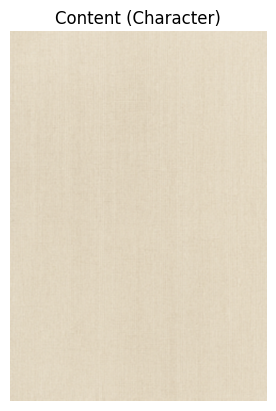

Upload STYLE image (Thai traditional costume / Thai pattern)...


Saving Screenshot 2568-12-28 at 20.04.28.png to Screenshot 2568-12-28 at 20.04.28.png


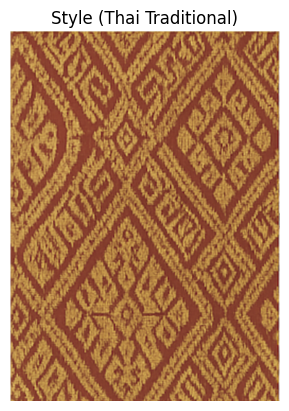

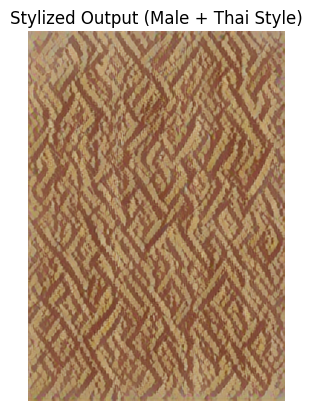

Saved stylized image as: stylized_style.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


import io
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from PIL import Image

# ==== STEP 1: ฟังก์ชันโหลดและเตรียมรูปภาพ ====

def load_image_from_upload(max_dim=512):
    """ให้ผู้ใช้อัปโหลดรูป แล้วคืนค่าเป็น tensor ที่เตรียมพร้อมใช้กับโมเดล"""
    uploaded = files.upload()
    # เลือกไฟล์ตัวแรก
    filename = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[filename]))

    # แปลงเป็น RGB เผื่อภาพเป็นโหมดอื่น (เช่น PNG โปร่งแสง)
    img = img.convert('RGB')

    # resize ให้ด้านยาวสุดไม่เกิน max_dim เพื่อรันเร็วขึ้น
    long_dim = max(img.size)
    scale = max_dim / long_dim
    new_size = (int(img.size[0] * scale), int(img.size[1] * scale))
    img = img.resize(new_size, Image.LANCZOS)

    img = np.array(img)
    img = img.astype(np.float32)[np.newaxis, ...] / 255.0  # [1, h, w, 3], 0–1
    return img, filename

def show_image(tensor, title=''):
    tensor = np.squeeze(tensor, axis=0)  # [1, h, w, 3] -> [h, w, 3]
    tensor = np.clip(tensor, 0.0, 1.0)
    plt.imshow(tensor)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

# ==== STEP 2: โหลดโมเดล Style Transfer จาก TF-Hub ====

print("Loading style transfer model from TF-Hub...")
hub_model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)
print("Model loaded.")

# ==== STEP 3: อัปโหลด Content (ตัวละคร) และ Style (ชุดไทย) ====
#อาจใช้รูป content_103.png, style_103.png
print("Upload CONTENT image (ตัวละคร)...")
content_image, content_name = load_image_from_upload(max_dim=512)
show_image(content_image, title="Content (Character)")

print("Upload STYLE image (Thai traditional costume / Thai pattern)...")
style_image, style_name = load_image_from_upload(max_dim=512)
show_image(style_image, title="Style (Thai Traditional)")

# ==== STEP 4: ทำ Style Transfer ====

stylized_image = hub_model(
    tf.constant(content_image),
    tf.constant(style_image)
)[0]

show_image(stylized_image, title="Stylized Output (Man/Woman + Thai Style)")

# ==== STEP 5: บันทึกไฟล์ผลลัพธ์ ====

# แปลงกลับเป็น 0–255 สำหรับบันทึก
output_img = np.squeeze(stylized_image.numpy(), axis=0)
output_img = np.clip(output_img * 255.0, 0, 255).astype(np.uint8)

output_pil = Image.fromarray(output_img)
output_filename = "stylized_style.png"
output_pil.save(output_filename)

print("Saved stylized image as:", output_filename)
files.download(output_filename)


# โค้ด 10.3 NST ดั้งเดิม

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/aiforeveryone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
accident.mp4		      coins_result.png	 style_103.png
aiforeveryone_lession8.ipynb  coint.png		 styled_output.png
aiforeveryone_lesson10.ipynb  content_103.png	 style_style.png
aiforeveryone_Lesson4.ipynb   content_style.png  target
aiforeveryone_lesson5.ipynb   emails_spam.csv	 test.png
aiforeveryone_lesson6.ipynb   fabric		 thaistyle
aiforeveryone_lesson7.ipynb   feature		 traffic_detect.mp4
aiforeveryone_lesson9.ipynb   leaf.png		 traffic_mask.png
aiforeveryron_lesson3.ipynb   mri_scan.jpg	 traffic.mp4
aiforeveyone_Lesson1.ipynb    number8n.png	 traffic.png
aiforeveyone_Lesson2.ipynb    number8.png	 traffics.png
ball.jpg		      riceb.jpg		 woman.mp4
ceramic_design.png	      rice.jpg		 ืีnumber8n.png
ceramic.png		      sketch
cnn			      source.jpg


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 71.7MB/s]


0 0.0023649055510759354 0.0026641367003321648
5 0.006114843767136335 0.006774820387363434
10 0.0083543062210083 0.009529480710625648
19 0.003720357082784176 0.005298118572682142
28 0.0006943588959984481 0.0011723045026883483
Step 1/1000 | Content Loss: 0.7234 | Style Loss: 0.0002


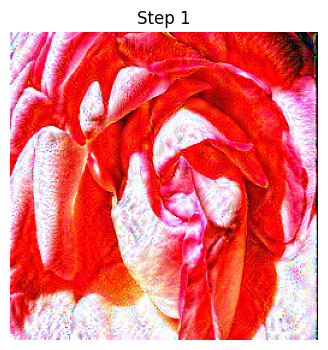

KeyboardInterrupt: 

In [2]:
#1  เตรียมไลบรารี
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
#2️⃣ โหลดและเตรียมภาพ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_size = 256

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = transform(image).unsqueeze(0)
    return image.to(device)
##อาจจะทดลองใช่ภาพลายไทยกับสีพื้น (content_style.png, style_style.png)
content_img = load_image("/content/drive/MyDrive/aiforeveryone/content_103.png")
style_img   = load_image("/content/drive/MyDrive/aiforeveryone/style_103.png")
#3️⃣ โหลด VGG19 (ใช้เป็น Feature Extractor)
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False
#4️⃣ ฟังก์ชัน Gram Matrix (สำหรับ Style)
def gram_matrix(feature):
    _, c, h, w = feature.size()
    feature = feature.view(c, h * w)
    gram = torch.mm(feature, feature.t())
    return gram / (c * h * w)
#5️⃣ เลเยอร์ที่ใช้คำนวณ Loss
content_layer = '21'   # conv4_2
style_layers  = ['0', '5', '10', '19', '28']
#6️⃣ ดึง Feature จาก VGG
def get_features(image, model):
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name == content_layer or name in style_layers:
            features[name] = x
    return features
#7️⃣ เตรียม Feature เป้าหมาย
content_features = get_features(content_img, vgg)
style_features   = get_features(style_img, vgg)

style_grams = {layer: gram_matrix(style_features[layer])
               for layer in style_layers}
for k, v in style_grams.items():
          print(k, v.mean().item(), v.std().item())

#8️⃣ ภาพผลลัพธ์ (เริ่มจาก Content)
generated = content_img.clone().requires_grad_(True)
#generated = torch.randn_like(content_img).requires_grad_(True)

#9️⃣ ตั้งค่า Loss และ Optimizer
content_weight = 1e2
style_weight   = 1e4  #ให้น้ำหนักกับ style สูงกว่า content

#optimizer = optim.Adam([generated], lr=0.003)
optimizer = optim.LBFGS([generated])
#1️⃣1️⃣ แสดงผลลัพธ์
def show_image(tensor, title=None):
    image = tensor.detach().cpu().squeeze(0)
    image = image.permute(1, 2, 0)
    image = torch.clamp(image, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


num_steps = 1000
display_every = 200

for step in range(1, num_steps + 1):
    def closure():
        generated.data.clamp_(0, 1) # Clamp values to [0, 1] for image output
        optimizer.zero_grad()

        gen_features = get_features(generated, vgg)

        # ===== Content Loss =====
        content_loss = torch.mean(
            (gen_features[content_layer] - content_features[content_layer]) ** 2
        )

        # ===== Style Loss =====
        style_loss = 0
        for layer in style_layers:
            gen_gram = gram_matrix(gen_features[layer])
            style_gram = style_grams[layer]

            style_loss += torch.mean((gen_gram - style_gram) ** 2)

        # ===== Total Loss =====
        total_loss = content_weight * content_loss + style_weight * style_loss

        total_loss.backward()
        return total_loss

    optimizer.step(closure)

    # Re-evaluate losses after the step for logging
    # It's important to do this *after* optimizer.step(closure) to get the most up-to-date values
    gen_features = get_features(generated, vgg)
    content_loss = torch.mean(
        (gen_features[content_layer] - content_features[content_layer]) ** 2
    )
    style_loss = 0
    for layer in style_layers:
        gen_gram = gram_matrix(gen_features[layer])
        style_gram = style_grams[layer]
        style_loss += torch.mean((gen_gram - style_gram) ** 2)

    # ===== แสดงผลเป็นช่วง =====
    if step % display_every == 0 or step == 1:
        print(
            f"Step {step}/{num_steps} | "
            f"Content Loss: {content_loss.item():.4f} | "
            f"Style Loss: {style_loss.item():.4f}"
        )
        show_image(generated, title=f"Step {step}")

#โค้ด 10.5 style transfer ใช้ GAN
โมเดล Vanilla GAN
รันนานมาก ควรหาภาพมาเพิ่มจึงจะได้ความหลากหลาย

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#1️⃣ เตรียมไลบรารี (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import ImageFolder # Keep for potential debugging, but not directly used for dataset
from torchvision.utils import save_image
from torch.utils.data import DataLoader, Dataset
import os
import shutil
from google.colab import drive
from PIL import Image # For opening images in custom dataset

# Force remount Google Drive to ensure file system is up-to-date
print("Forcing Google Drive remount to ensure file system sync...")
drive.mount('/content/drive', force_remount=True)
print("Google Drive remounted.")

#2️⃣ เตรียม Dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Define the base directory for your fabric images
base_fabric_dir = "/content/drive/MyDrive/aiforeveryone/fabric"
# Define a new subdirectory where images will be placed for the custom dataset
target_image_folder = os.path.join(base_fabric_dir, "images_for_gan")

# Check if the target image folder exists and is populated, if not, create it
if not os.path.exists(target_image_folder) or not os.listdir(target_image_folder):
    print(f"Preparing data for custom Dataset: Moving images from '{base_fabric_dir}' to '{target_image_folder}'...")
    os.makedirs(target_image_folder, exist_ok=True)

    # List all files directly in the base_fabric_dir
    all_files_in_base = [f for f in os.listdir(base_fabric_dir) if os.path.isfile(os.path.join(base_fabric_dir, f))]

    if not all_files_in_base:
        print(f"Warning: No image files found directly in '{base_fabric_dir}'. This might be because they were moved in a previous run, or no images are present at all.")

    for filename in all_files_in_base:
        # Check for common image extensions
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
            src_path = os.path.join(base_fabric_dir, filename)
            dest_path = os.path.join(target_image_folder, filename)
            # Move the file into the new subfolder
            try:
                shutil.move(src_path, dest_path)
            except Exception as e:
                print(f"Error moving {filename}: {e}")
        else:
            print(f"Skipping non-image file in base_fabric_dir: {filename}")


    print("Data preparation complete.")
else:
    print(f"Data directory '{target_image_folder}' already prepared for custom Dataset.")

# --- Debugging before Custom Dataset initialization ---
print(f"\n--- Debugging Custom Dataset setup ---")
print(f"Root directory for images: {target_image_folder}")

if not os.path.exists(target_image_folder):
    print(f"ERROR: target_image_folder '{target_image_folder}' does not exist.")
elif not os.path.isdir(target_image_folder):
    print(f"ERROR: target_image_folder '{target_image_folder}' is not a directory.")
else:
    files_in_target = [f for f in os.listdir(target_image_folder) if os.path.isfile(os.path.join(target_image_folder, f))]
    print(f"Number of files found in '{target_image_folder}': {len(files_in_target)}")
    if not files_in_target:
        print(f"WARNING: No files found inside '{target_image_folder}'. This is the likely cause of issues.")
    else:
        print(f"First 5 files in '{target_image_folder}': {files_in_target[:5]}")
        # Check if first file is readable as an image
        try:
            test_img_path = os.path.join(target_image_folder, files_in_target[0])
            Image.open(test_img_path).verify()
            print(f"Test: First file '{files_in_target[0]}' appears to be a valid image.")
        except Exception as e:
            print(f"Test: Failed to open or verify '{files_in_target[0]}' as an image: {e}")

print(f"--- End Debugging Custom Dataset setup ---\n")

# Custom Dataset class to load images directly without ImageFolder's strict structure requirements
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = []
        for filename in os.listdir(root_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                self.image_files.append(os.path.join(root_dir, filename))
        if not self.image_files:
            raise RuntimeError(f"No image files found in '{root_dir}'. Please check the directory and file types.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        label = 0 # Dummy label for a single class GAN or if labels are not used

        if self.transform:
            image = self.transform(image)
        return image, label

# Initialize the custom dataset and dataloader
dataset = CustomImageDataset(root_dir=target_image_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

##️⃣️ Generator (ง่ายสุด)
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 64*64*3),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 3, 64, 64)
#4️⃣ Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64*64*3, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)
#5#️⃣ ️⃣️⃣ สร้างโมเดล
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.003)
opt_D = optim.Adam(D.parameters(), lr=0.0001)
#6️⃣ Training Loop (หัวใจ GAN)
epochs = 1500 # Revert to 50 for demo purposes
z_dim = 100 # Revert to 100 for standard GAN latent dim

os.makedirs("/content/drive/MyDrive/aiforeveryone/fabric/output", exist_ok=True) # Keep output in Drive for persistence

for epoch in range(epochs):
    for real, _ in dataloader:
        real = real.to(device)
        batch = real.size(0)

        # === Train Discriminator ===
        z = torch.randn(batch, z_dim).to(device)
        fake = G(z)

        real_label = torch.ones(batch, 1).to(device)
        fake_label = torch.zeros(batch, 1).to(device)

        loss_D = criterion(D(real), real_label) + \
                 criterion(D(fake.detach()), fake_label)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # === Train Generator ===
        loss_G = criterion(D(fake), real_label)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D: {loss_D.item():.3f}  G: {loss_G.item():.3f}")

    if epoch % 100 == 0:
        save_image(fake[:16], os.path.join("/content/drive/MyDrive/aiforeveryone/fabric/output", f"epoch_{epoch}.png"), normalize=True)


#โค้ด 10.6 Sketch-AI
ออกแบบ Ceramic

In [ ]:
# ===========================================
# 1) ติดตั้งไลบรารี (รันครั้งแรกครั้งเดียว)
# ===========================================
!pip install diffusers transformers accelerate safetensors opencv-python pillow -q


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


ใช้ไฟล์: /content/ceramic.png


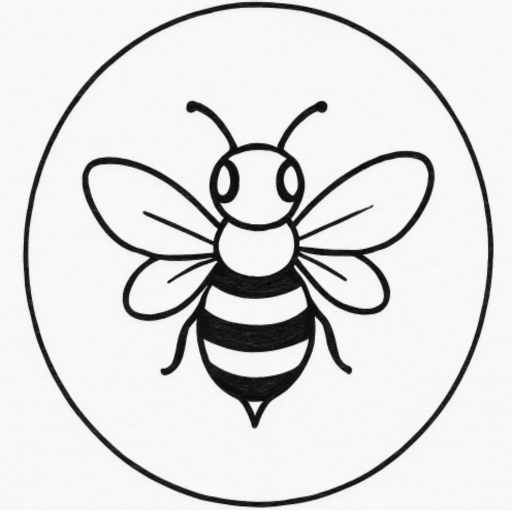

  0%|          | 0/27 [00:00<?, ?it/s]

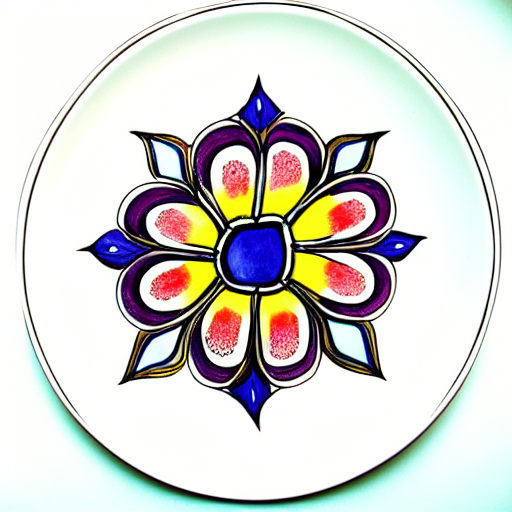

บันทึกเป็นไฟล์: /content/drive/MyDrive/aiforeveryone/ceramic_design.png


In [ ]:
# ===========================================
# 2) Import และโหลดโมเดล Stable Diffusion + ControlNet (scribble)
# ===========================================
import torch
from diffusers import StableDiffusionControlNetImg2ImgPipeline, ControlNetModel, UniPCMultistepScheduler
from PIL import Image
import cv2
import numpy as np

# โหลด ControlNet ที่รับสเกตช์ / scribble
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-scribble",
    torch_dtype=torch.float16
)

# โหลด Stable Diffusion v1.5 + ต่อ ControlNet เข้าไป
pipe = StableDiffusionControlNetImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    controlnet=controlnet,
    safety_checker=None,          # ปิด safety checker (ถ้าต้องการเปิด ให้ลบบรรทัดนี้)
    torch_dtype=torch.float16
)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")

# ===========================================
# 3) อัปโหลดภาพสเกตช์จากเครื่อง (บน Colab)
#    เลือกไฟล์ .jpg / .png ที่เป็นเส้นสเกตช์
# ===========================================
from google.colab import files
from IPython.display import display

from PIL import Image

file_name = "/content/ceramic.png" # Corrected path to where the file is found
print("ใช้ไฟล์:", file_name)

# Load the image using PIL
original_pil_img = Image.open(file_name).convert("RGB")

# Convert to numpy array for cv2 resizing, then back to PIL
img_np = np.array(original_pil_img)
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # This line is unnecessary if original_pil_img is already RGB

# ปรับขนาดให้เป็น 512x512 (ขนาดมาตรฐานของ SD v1.5)
img_resized = cv2.resize(img_np, (512, 512))

# แปลงเป็น PIL Image
sketch_image = Image.fromarray(img_resized)
display(sketch_image)
# ===========================================
# 4) สร้างลายจานเซรามิกจากสเกตช์
#    ปรับข้อความ prompt/negative_prompt และค่าพารามิเตอร์ได้
# ===========================================
prompt = (
    "top view of a white ceramic plate, detailed colorful pattern "
    "following the sketch, hand-painted style, glossy ceramic, studio lighting"
)

negative_prompt = (
    "blurry, low quality, text, watermark, logo, distorted, extra hands, extra objects"
)

# ใช้ภาพสเกตช์เป็นทั้ง image (ต้นฉบับ) และ control_image (ไกด์โครงร่าง)
result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=sketch_image,      # ภาพต้นทาง (ใช้ร่วมกับ strength)
    control_image=sketch_image,
    num_inference_steps=30,  # จำนวน step (เยอะ = ละเอียดขึ้น แต่ช้าขึ้น)
    guidance_scale=7.5,      # CFG scale (สูง = ตาม prompt มากขึ้น)
    strength=0.9,            # 0.0–1.0: 1.0 = เปลี่ยนจากภาพเดิมเยอะ, 0.3 = เก็บภาพเดิมมาก
).images[0]

# แสดงผลและบันทึกไฟล์
display(result)
save_name = "/content/drive/MyDrive/aiforeveryone/ceramic_design.png"
result.save(save_name)
print("บันทึกเป็นไฟล์:", save_name)


#โค้ด 10.7 Font generation

num glyphs: 1
Epoch 1/150
Epoch 2/150
Epoch 3/150
Epoch 4/150
Epoch 5/150
Epoch 6/150
Epoch 7/150
Epoch 8/150
Epoch 9/150
Epoch 10/150
Epoch 11/150
Epoch 12/150
Epoch 13/150
Epoch 14/150
Epoch 15/150
Epoch 16/150
Epoch 17/150
Epoch 18/150
Epoch 19/150
Epoch 20/150
Epoch 21/150
Epoch 22/150
Epoch 23/150
Epoch 24/150
Epoch 25/150
Epoch 26/150
Epoch 27/150
Epoch 28/150
Epoch 29/150
Epoch 30/150
Epoch 31/150
Epoch 32/150
Epoch 33/150
Epoch 34/150
Epoch 35/150
Epoch 36/150
Epoch 37/150
Epoch 38/150
Epoch 39/150
Epoch 40/150
Epoch 41/150
Epoch 42/150
Epoch 43/150
Epoch 44/150
Epoch 45/150
Epoch 46/150
Epoch 47/150
Epoch 48/150
Epoch 49/150
Epoch 50/150
Epoch 51/150
Epoch 52/150
Epoch 53/150
Epoch 54/150
Epoch 55/150
Epoch 56/150
Epoch 57/150
Epoch 58/150
Epoch 59/150
Epoch 60/150
Epoch 61/150
Epoch 62/150
Epoch 63/150
Epoch 64/150
Epoch 65/150
Epoch 66/150
Epoch 67/150
Epoch 68/150
Epoch 69/150
Epoch 70/150
Epoch 71/150
Epoch 72/150
Epoch 73/150
Epoch 74/150
Epoch 75/150
Epoch 76/150
Epoch 7

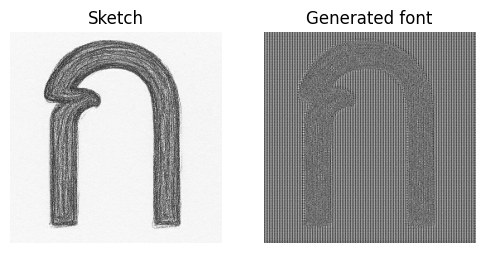

In [ ]:
# =========================================
# 1) Import
# =========================================
import os, glob, random
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = 256
BATCH_SIZE = 4
SKETCH_DIR = "/content/drive/MyDrive/aiforeveryone/sketch"
TARGET_DIR = "/content/drive/MyDrive/aiforeveryone/target"

# =========================================
# 2) เตรียมรายการไฟล์ (ใช้ชื่อไฟล์เป็นตัวจับคู่)
# =========================================
filenames = sorted([os.path.basename(p) for p in glob.glob(os.path.join(SKETCH_DIR, "*.png"))])
print("num glyphs:", len(filenames))

# =========================================
# 3) ฟังก์ชันโหลดภาพ (sketch, target) เป็นเทนเซอร์
# =========================================
def load_image_pair(name):
    sketch_path = os.path.join(SKETCH_DIR, name)
    target_path = os.path.join(TARGET_DIR, name)

    sketch = tf.io.read_file(sketch_path)
    sketch = tf.io.decode_png(sketch, channels=1)
    sketch = tf.image.resize(sketch, [IMG_SIZE, IMG_SIZE])
    sketch = (tf.cast(sketch, tf.float32) / 127.5) - 1.0   # [-1, 1]

    target = tf.io.read_file(target_path)
    target = tf.io.decode_png(target, channels=1)
    target = tf.image.resize(target, [IMG_SIZE, IMG_SIZE])
    target = (tf.cast(target, tf.float32) / 127.5) - 1.0   # [-1, 1]

    return sketch, target

def tf_load_pair(name):
    sketch, target = tf.py_function(
        func=load_image_pair,
        inp=[name],
        Tout=[tf.float32, tf.float32])
    sketch.set_shape([IMG_SIZE, IMG_SIZE, 1])
    target.set_shape([IMG_SIZE, IMG_SIZE, 1])
    return sketch, target

# split train / val
random.shuffle(filenames)
split = int(0.8 * len(filenames))
train_names = tf.constant(filenames[:split])
val_names   = tf.constant(filenames[split:])

train_ds = (tf.data.Dataset.from_tensor_slices(train_names)
            .map(tf_load_pair, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices(val_names)
          .map(tf_load_pair, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE))

# =========================================
# 4) สร้าง U-Net Generator
# =========================================
def down_block(filters, apply_batchnorm=True):
    block = tf.keras.Sequential()
    block.add(layers.Conv2D(filters, 4, strides=2, padding="same", use_bias=not apply_batchnorm))
    if apply_batchnorm:
        block.add(layers.BatchNormalization())
    block.add(layers.LeakyReLU())
    return block

def up_block(filters, apply_dropout=False):
    block = tf.keras.Sequential()
    block.add(layers.Conv2DTranspose(filters, 4, strides=2, padding="same", use_bias=False))
    block.add(layers.BatchNormalization())
    if apply_dropout:
        block.add(layers.Dropout(0.5))
    block.add(layers.ReLU())
    return block

def build_generator():
    inputs = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 1])

    # downsampling
    d1 = down_block(64,  apply_batchnorm=False)(inputs)  # (128,128,64)
    d2 = down_block(128)(d1)                             # (64,64,128)
    d3 = down_block(256)(d2)                             # (32,32,256)
    d4 = down_block(512)(d3)                             # (16,16,512)
    d5 = down_block(512)(d4)                             # (8,8,512)
    d6 = down_block(512)(d5)                             # (4,4,512)
    d7 = down_block(512)(d6)                             # (2,2,512)
    d8 = down_block(512)(d7)                             # (1,1,512)

    # upsampling + skip connections
    u1 = up_block(512, apply_dropout=True)(d8)
    u1 = layers.Concatenate()([u1, d7])

    u2 = up_block(512, apply_dropout=True)(u1)
    u2 = layers.Concatenate()([u2, d6])

    u3 = up_block(512, apply_dropout=True)(u2)
    u3 = layers.Concatenate()([u3, d5])

    u4 = up_block(512)(u3)
    u4 = layers.Concatenate()([u4, d4])

    u5 = up_block(256)(u4)
    u5 = layers.Concatenate()([u5, d3])

    u6 = up_block(128)(u5)
    u6 = layers.Concatenate()([u6, d2])

    u7 = up_block(64)(u6)
    u7 = layers.Concatenate()([u7, d1])

    last = layers.Conv2DTranspose(1, 4, strides=2, padding="same",
                                  activation="tanh")      # output [-1,1]

    outputs = last(u7)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="generator")

# =========================================
# 5) สร้าง PatchGAN Discriminator
# =========================================
def build_discriminator():
    inp = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 1], name="sketch")
    tar = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 1], name="target")

    x = layers.Concatenate()([inp, tar])   # concat channel

    x = down_block(64,  apply_batchnorm=False)(x)
    x = down_block(128)(x)
    x = down_block(256)(x)
    x = layers.ZeroPadding2D()(x)
    x = layers.Conv2D(512, 4, strides=1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.ZeroPadding2D()(x)
    x = layers.Conv2D(1, 4, strides=1)(x)  # Patch logits

    return tf.keras.Model(inputs=[inp, tar], outputs=x, name="discriminator")

generator = build_generator()
discriminator = build_discriminator()

# =========================================
# 6) Loss และ optimizer
# =========================================
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, fake):
    real_loss = loss_obj(tf.ones_like(real), real)
    fake_loss = loss_obj(tf.zeros_like(fake), fake)
    return (real_loss + fake_loss) * 0.5

LAMBDA_L1 = 100.0

def generator_loss(fake_output, gen_output, target):
    gan_loss = loss_obj(tf.ones_like(fake_output), fake_output)
    l1_loss  = tf.reduce_mean(tf.abs(target - gen_output))
    return gan_loss + LAMBDA_L1 * l1_loss, gan_loss, l1_loss

generator_optimizer     = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# =========================================
# 7) 1 training step
# =========================================
@tf.function
def train_step(sketch, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(sketch, training=True)

        real_output = discriminator([sketch, target], training=True)
        fake_output = discriminator([sketch, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(
            fake_output, gen_output, target)
        disc_loss = discriminator_loss(real_output, fake_output)

    grad_gen = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    grad_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(grad_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(grad_disc, discriminator.trainable_variables))

    return gen_total_loss, disc_loss, gen_gan_loss, gen_l1_loss

# =========================================
# 8) วนเทรน
# =========================================
EPOCHS =150

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    for step, (sketch_batch, target_batch) in enumerate(train_ds):
        g_loss, d_loss, g_gan, g_l1 = train_step(sketch_batch, target_batch)

        if step % 20 == 0:
            print(f" step {step:03d} | G_total={g_loss:.3f}  D={d_loss:.3f}  "
                  f"GAN={g_gan:.3f}  L1={g_l1:.3f}")

# =========================================
# 9) ฟังก์ชัน generate ภาพฟอนต์จาก sketch ใหม่
# =========================================
import numpy as np
import matplotlib.pyplot as plt

def generate_from_sketch(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = (tf.cast(img, tf.float32) / 127.5) - 1.0
    img = tf.expand_dims(img, 0)  # batch=1

    pred = generator(img, training=False)[0]
    pred = (pred + 1.0) * 127.5
    pred = tf.clip_by_value(pred, 0, 255)
    pred = tf.cast(pred, tf.uint8).numpy()

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1); plt.title("Sketch"); plt.imshow(img[0,...,0]*0.5+0.5, cmap="gray"); plt.axis("off")
    plt.subplot(1,2,2); plt.title("Generated font"); plt.imshow(pred[...,0], cmap="gray"); plt.axis("off")
    plt.show()

# ตัวอย่างเรียก
generate_from_sketch("/content/drive/MyDrive/aiforeveryone/sketch/ko.png")
